# Gráficas por épocas políticas

Este notebook recrea los mismos ejes analíticos de `report_graphs_20260421.ipynb`, pero reorganiza el análisis en **4 épocas**:

- `ERA_1`: legislaturas `LVII-LIX`
- `ERA_2`: legislaturas `LX-LXII`
- `ERA_3`: legislaturas `LXIII-LXV`
- `ERA_4`: legislatura `LXVI`

Fuente principal:
- `data/database/clean/diputados_20260421_203222.parquet`
- `reports/eda/eda_report_20260421.md`

Objetivo:
- comparar calidad de datos, perfil político, geografía, educación, edad, experiencia, trayectorias y comisiones entre épocas
- detectar cambios estructurales que quedan escondidos cuando se agrega todo el periodo


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.frameon"] = False
pd.set_option("display.max_columns", 100)


In [2]:
DATA_PATH = Path("data/database/clean/diputados_20260421_203222.parquet")
REPORT_PATH = Path("reports/eda/eda_report_20260421.md")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"No existe archivo parquet: {DATA_PATH}")
if not REPORT_PATH.exists():
    raise FileNotFoundError(f"No existe reporte base: {REPORT_PATH}")

df = pd.read_parquet(DATA_PATH).copy()
print(f"Fuente de datos: {DATA_PATH}")
print(f"Reporte base: {REPORT_PATH}")
print(f"Dimensión: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")


Fuente de datos: data/database/clean/diputados_20260421_203222.parquet
Reporte base: reports/eda/eda_report_20260421.md
Dimensión: 5,000 filas x 76 columnas


In [3]:
roman_map = {
    57: "LVII", 58: "LVIII", 59: "LIX", 60: "LX", 61: "LXI",
    62: "LXII", 63: "LXIII", 64: "LXIV", 65: "LXV", 66: "LXVI",
}

era_map = {
    57: "ERA_1", 58: "ERA_1", 59: "ERA_1",
    60: "ERA_2", 61: "ERA_2", 62: "ERA_2",
    63: "ERA_3", 64: "ERA_3", 65: "ERA_3",
    66: "ERA_4",
}

era_label_map = {
    "ERA_1": "ERA_1 · LVII-LIX",
    "ERA_2": "ERA_2 · LX-LXII",
    "ERA_3": "ERA_3 · LXIII-LXV",
    "ERA_4": "ERA_4 · LXVI",
}

era_order = ["ERA_1", "ERA_2", "ERA_3", "ERA_4"]

plot_df = df.copy()
plot_df["legislatura_roman"] = plot_df["legislatura_num"].map(roman_map)
plot_df["era"] = plot_df["legislatura_num"].map(era_map)
plot_df["era_label"] = plot_df["era"].map(era_label_map)

if plot_df["era"].isna().any():
    missing_legs = sorted(plot_df.loc[plot_df["era"].isna(), "legislatura_num"].dropna().unique().tolist())
    raise ValueError(f"Legislaturas sin era asignada: {missing_legs}")

plot_df["era"] = pd.Categorical(plot_df["era"], categories=era_order, ordered=True)
plot_df["era_label"] = pd.Categorical(
    plot_df["era_label"],
    categories=[era_label_map[e] for e in era_order],
    ordered=True,
)

plot_df[["legislatura_num", "legislatura_roman", "era", "era_label"]].drop_duplicates().sort_values("legislatura_num")


,legislatura_num,legislatura_roman,era,era_label
1000,57,LVII,ERA_1,ERA_1 · LVII-LIX
500,58,LVIII,ERA_1,ERA_1 · LVII-LIX
0,59,LIX,ERA_1,ERA_1 · LVII-LIX
4500,60,LX,ERA_2,ERA_2 · LX-LXII
3000,61,LXI,ERA_2,ERA_2 · LX-LXII
2000,62,LXII,ERA_2,ERA_2 · LX-LXII
1500,63,LXIII,ERA_3,ERA_3 · LXIII-LXV
2500,64,LXIV,ERA_3,ERA_3 · LXIII-LXV
4000,65,LXV,ERA_3,ERA_3 · LXIII-LXV
3500,66,LXVI,ERA_4,ERA_4 · LXVI


## 1. Resumen por época

In [4]:
resumen_era = (
    plot_df.groupby("era_label")
    .agg(
        filas=("diputado_id", "size"),
        legislaturas=("legislatura_num", lambda s: ", ".join(sorted({roman_map[x] for x in s}))),
        diputados_unicos=("diputado_id", "nunique"),
        edad_promedio=("edad_al_tomar_cargo", "mean"),
        comisiones_promedio=("n_comisiones", "mean"),
        nodales_promedio=("n_comisiones_nodales", "mean"),
        tematicas_promedio=("n_comisiones_tematicas", "mean"),
        lastre_promedio=("n_comisiones_lastre", "mean"),
    )
    .reset_index()
)

display(resumen_era.round(2))


,era_label,filas,legislaturas,diputados_unicos,edad_promedio,comisiones_promedio,nodales_promedio,tematicas_promedio,lastre_promedio
0,ERA_1 · LVII-LIX,1500,"LIX, LVII, LVIII",1468,44.82,3.57,0.47,1.53,0.51
1,ERA_2 · LX-LXII,1500,"LX, LXI, LXII",1476,45.76,4.40,0.63,1.93,0.58
2,ERA_3 · LXIII-LXV,1500,"LXIII, LXIV, LXV",1371,47.37,4.19,0.82,2.15,0.68
3,ERA_4 · LXVI,500,LXVI,500,48.37,3.23,0.88,1.87,0.45


## 2. Calidad de datos por época

,era_label,y_nacimiento,edad_al_tomar_cargo,distrito_circ
0,ERA_1 · LVII-LIX,10.20,10.40,13.0
1,ERA_2 · LX-LXII,4.47,4.47,0.0
2,ERA_3 · LXIII-LXV,18.80,18.87,0.0
3,ERA_4 · LXVI,0.80,0.80,3.2


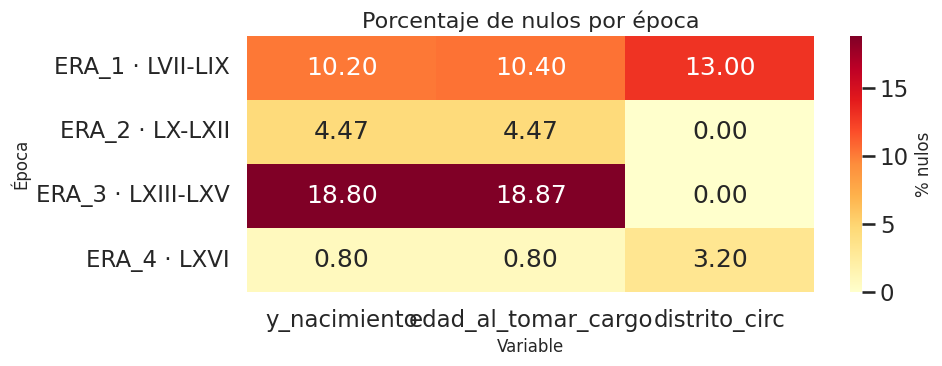

In [5]:
missing_by_era = (
    plot_df.groupby("era_label")[["y_nacimiento", "edad_al_tomar_cargo", "distrito_circ"]]
    .apply(lambda g: g.isna().mean() * 100)
    .rename_axis(index="era_label")
    .reset_index()
)

display(missing_by_era.round(2))

heat = missing_by_era.set_index("era_label")
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={"label": "% nulos"}, ax=ax)
ax.set_title("Porcentaje de nulos por época")
ax.set_xlabel("Variable")
ax.set_ylabel("Época")
plt.tight_layout()
plt.show()


## 3. Distribución política por época

,era_label,partido_nombre,n,pct_era
5,ERA_1 · LVII-LIX,Partido Revolucionario Institucional,648,43.200000
3,ERA_1 · LVII-LIX,Partido Acción Nacional,469,31.266667
7,ERA_1 · LVII-LIX,Partido de la Revolución Democrática,272,18.133333
6,ERA_1 · LVII-LIX,Partido Verde Ecologista de México,38,2.533333
2,ERA_1 · LVII-LIX,Independiente,36,2.400000
9,ERA_1 · LVII-LIX,Partido del Trabajo,26,1.733333
17,ERA_2 · LX-LXII,Partido Revolucionario Institucional,560,37.333333
14,ERA_2 · LX-LXII,Partido Acción Nacional,461,30.733333
19,ERA_2 · LX-LXII,Partido de la Revolución Democrática,287,19.133333
18,ERA_2 · LX-LXII,Partido Verde Ecologista de México,67,4.466667


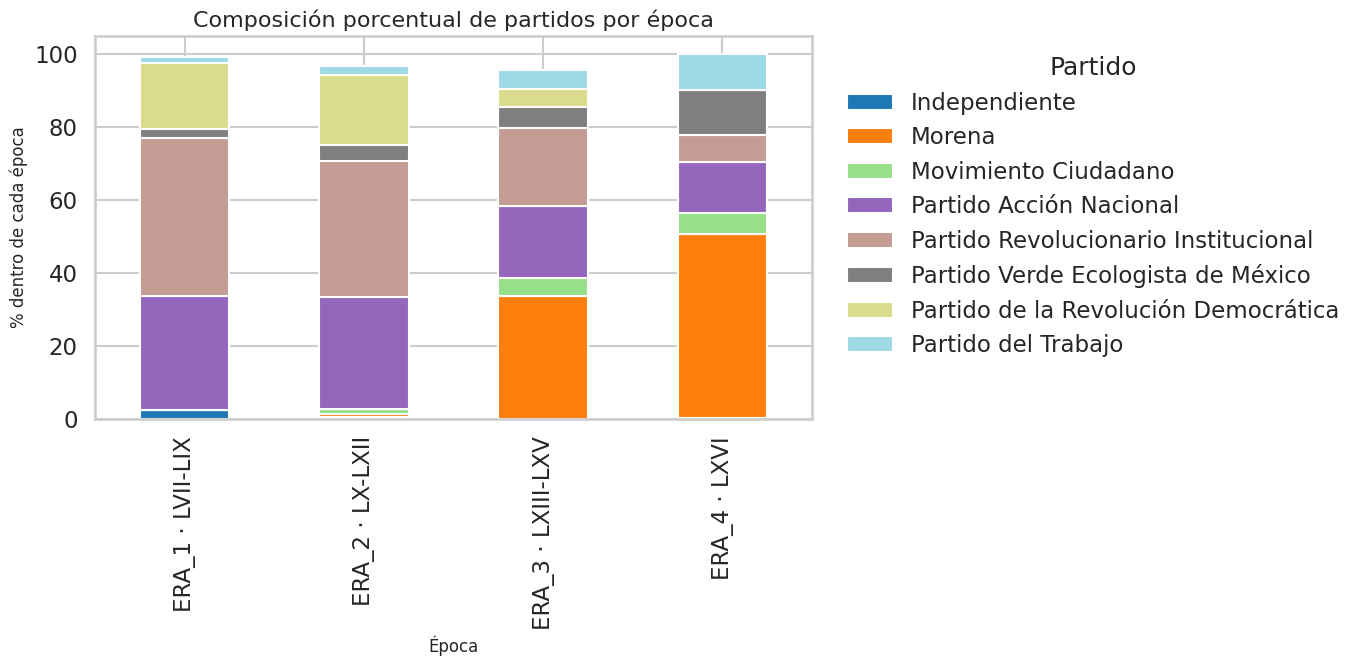

In [6]:
party_era = (
    plot_df.groupby(["era_label", "partido_nombre"])
    .size()
    .reset_index(name="n")
)

party_era["pct_era"] = party_era.groupby("era_label")["n"].transform(lambda s: 100 * s / s.sum())
party_top = (
    party_era.groupby("partido_nombre")["n"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
)

party_era_top = party_era[party_era["partido_nombre"].isin(party_top)].copy()

display(party_era_top.sort_values(["era_label", "n"], ascending=[True, False]).head(20))

pivot_party = (
    party_era_top.pivot(index="era_label", columns="partido_nombre", values="pct_era")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(14, 7))
pivot_party.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Composición porcentual de partidos por época")
ax.set_xlabel("Época")
ax.set_ylabel("% dentro de cada época")
ax.legend(title="Partido", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 4. Geografía por época

entidad_codigo,CDMX,CHIS,DESCONOCIDO,GTO,JAL,MEX,MICH,NL,PUE,VER
era_label,,,,,,,,,,
ERA_1 · LVII-LIX,151,46,195,58,73,149,56,47,50,90
ERA_2 · LX-LXII,155,58,0,63,84,197,60,59,59,94
ERA_3 · LXIII-LXV,148,57,0,57,95,193,59,65,64,98
ERA_4 · LXVI,49,18,16,17,32,58,18,25,23,29


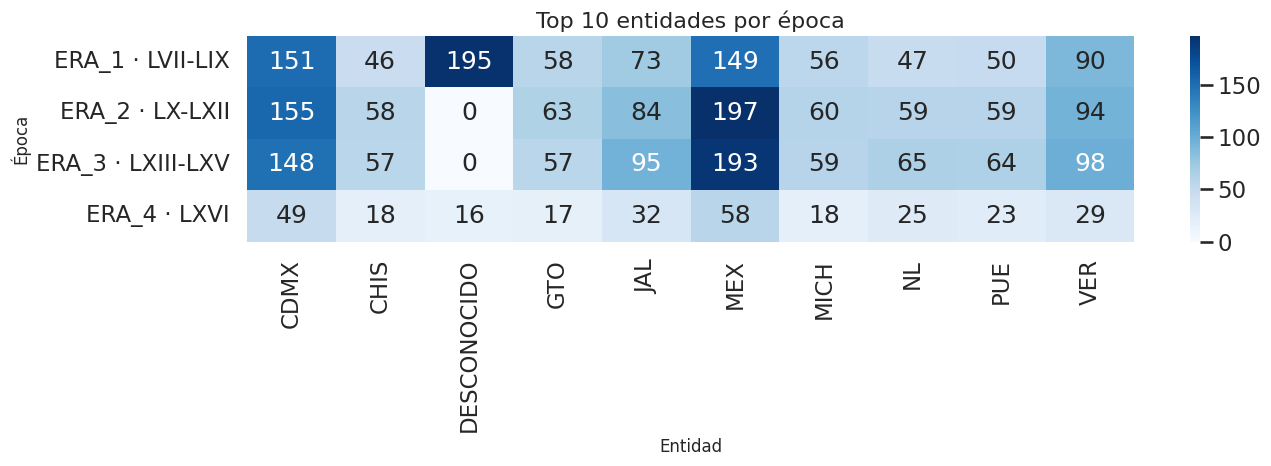

In [7]:
entity_era = (
    plot_df.assign(entidad_codigo=plot_df["entidad_codigo"].fillna("DESCONOCIDO"))
    .groupby(["era_label", "entidad_codigo"])
    .size()
    .reset_index(name="n")
)

entity_top = (
    entity_era.groupby("entidad_codigo")["n"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

entity_era_top = entity_era[entity_era["entidad_codigo"].isin(entity_top)].copy()
entity_heat = entity_era_top.pivot(index="era_label", columns="entidad_codigo", values="n").fillna(0)

display(entity_heat.astype(int))

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(entity_heat, annot=True, fmt=".0f", cmap="Blues", ax=ax)
ax.set_title("Top 10 entidades por época")
ax.set_xlabel("Entidad")
ax.set_ylabel("Época")
plt.tight_layout()
plt.show()


## 5. Perfil educativo por época

,era_label,grado_promedio,posgrado_pct,doctorado_pct,extranjero_pct
0,ERA_1 · LVII-LIX,3.10,25.40,4.00,10.27
1,ERA_2 · LX-LXII,3.93,31.47,5.07,8.13
2,ERA_3 · LXIII-LXV,3.75,38.07,5.67,6.73
3,ERA_4 · LXVI,4.09,38.00,8.40,5.80


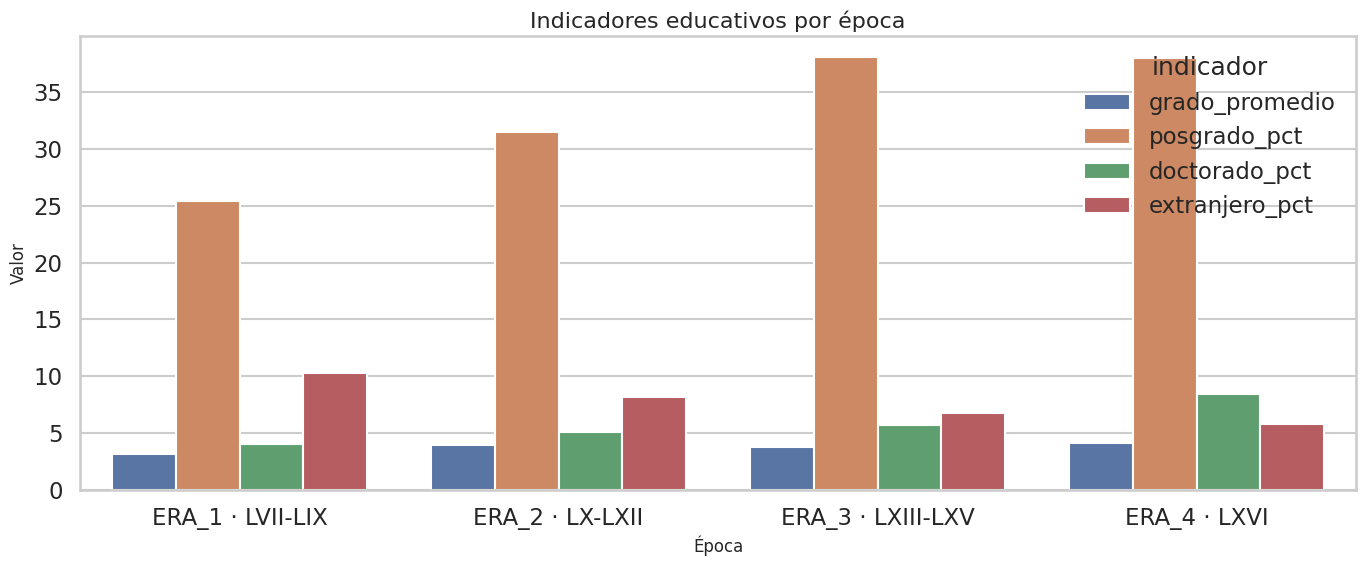

In [8]:
grade_labels = {
    0: "Sin dato",
    1: "Primaria",
    2: "Secundaria",
    4: "Preparatoria",
    5: "Lic. incompleta",
    6: "Licenciatura",
    7: "Especialidad",
    9: "Doctorado",
}

educacion_era = (
    plot_df.groupby("era_label")
    .agg(
        grado_promedio=("grado_estudios_ord", "mean"),
        posgrado_pct=("tiene_posgrado", lambda s: 100 * s.mean()),
        doctorado_pct=("tiene_doctorado", lambda s: 100 * s.mean()),
        extranjero_pct=("estudios_en_extranjero", lambda s: 100 * s.mean()),
    )
    .reset_index()
)

display(educacion_era.round(2))

edu_long = educacion_era.melt(id_vars="era_label", var_name="indicador", value_name="valor")
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=edu_long, x="era_label", y="valor", hue="indicador", ax=ax)
ax.set_title("Indicadores educativos por época")
ax.set_xlabel("Época")
ax.set_ylabel("Valor")
plt.tight_layout()
plt.show()


grado_etiqueta,Doctorado,Lic. incompleta,Licenciatura,Preparatoria,Sin dato
era_label,,,,,
ERA_1 · LVII-LIX,2.47,6.0,40.33,3.13,46.13
ERA_2 · LX-LXII,3.93,8.0,49.93,2.80,31.53
ERA_3 · LXIII-LXV,5.07,6.2,47.53,1.07,34.67
ERA_4 · LXVI,6.20,4.2,53.60,0.60,30.80


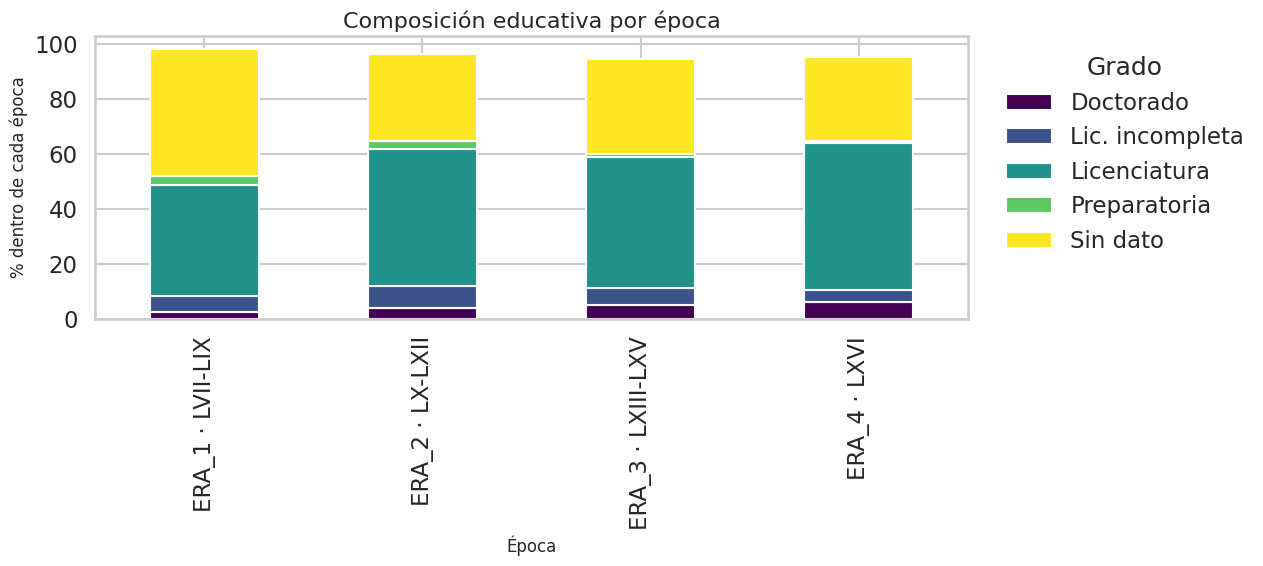

In [9]:
grado_dist_era = (
    plot_df.assign(grado_etiqueta=plot_df["grado_estudios_ord"].fillna(-1).astype(int).map(grade_labels).fillna("Otro"))
    .groupby(["era_label", "grado_etiqueta"])
    .size()
    .reset_index(name="n")
)
grado_dist_era["pct_era"] = grado_dist_era.groupby("era_label")["n"].transform(lambda s: 100 * s / s.sum())

grado_focus = ["Sin dato", "Licenciatura", "Doctorado", "Lic. incompleta", "Preparatoria"]
grado_dist_focus = grado_dist_era[grado_dist_era["grado_etiqueta"].isin(grado_focus)].copy()
grado_pivot = grado_dist_focus.pivot(index="era_label", columns="grado_etiqueta", values="pct_era").fillna(0)

display(grado_pivot.round(2))

fig, ax = plt.subplots(figsize=(13, 6))
grado_pivot.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_title("Composición educativa por época")
ax.set_xlabel("Época")
ax.set_ylabel("% dentro de cada época")
ax.legend(title="Grado", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 6. Edad por época

,era_label,mean,median,min,max,std,count
0,ERA_1 · LVII-LIX,44.82,45.0,21.0,77.0,9.73,1344
1,ERA_2 · LX-LXII,45.76,46.0,21.0,84.0,10.07,1433
2,ERA_3 · LXIII-LXV,47.37,47.0,22.0,85.0,11.03,1217
3,ERA_4 · LXVI,48.37,48.0,21.0,79.0,11.24,496


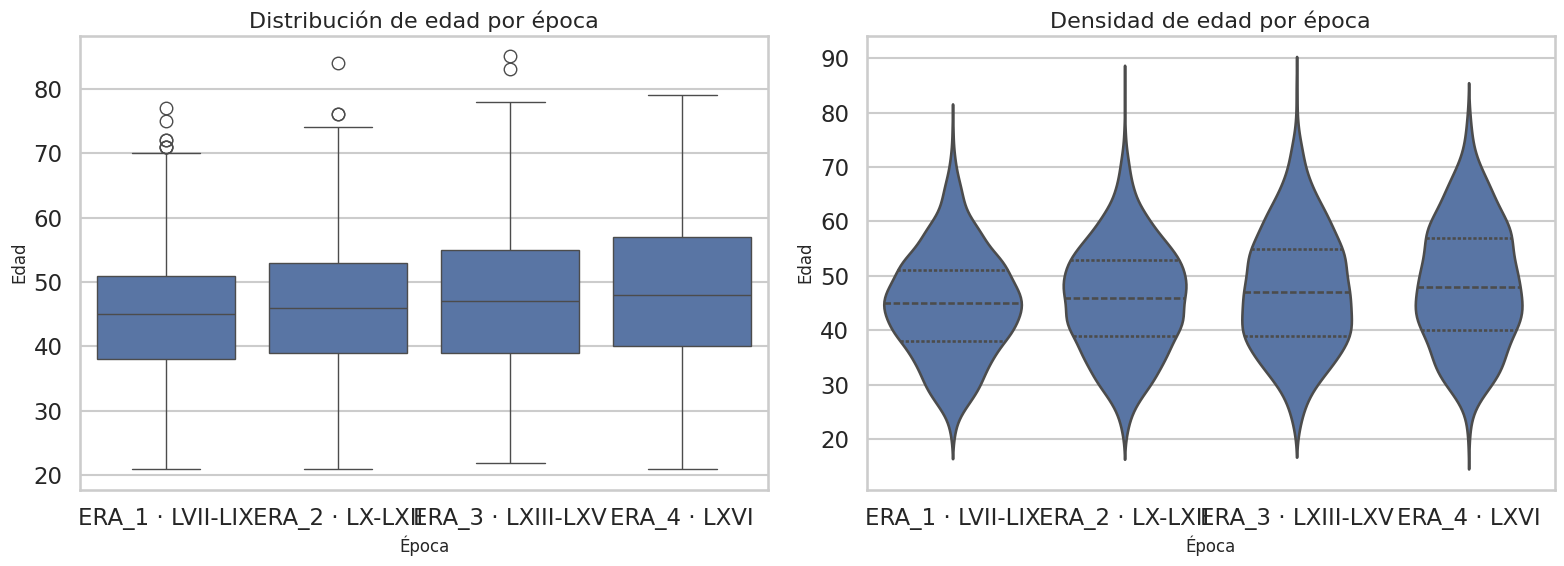

In [10]:
edad_era = (
    plot_df.groupby("era_label")["edad_al_tomar_cargo"]
    .agg(["mean", "median", "min", "max", "std", "count"])
    .reset_index()
)

display(edad_era.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=plot_df, x="era_label", y="edad_al_tomar_cargo", ax=axes[0])
axes[0].set_title("Distribución de edad por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Edad")

sns.violinplot(data=plot_df, x="era_label", y="edad_al_tomar_cargo", inner="quartile", ax=axes[1])
axes[1].set_title("Densidad de edad por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Edad")

plt.tight_layout()
plt.show()


## 7. Experiencia legislativa previa por época

,era_label,cargos_prev_promedio,primera_vez_pct,con_reeleccion_pct
0,ERA_1 · LVII-LIX,0.35,72.93,27.07
1,ERA_2 · LX-LXII,0.57,54.47,45.53
2,ERA_3 · LXIII-LXV,0.59,56.80,43.20
3,ERA_4 · LXVI,0.79,42.80,57.20


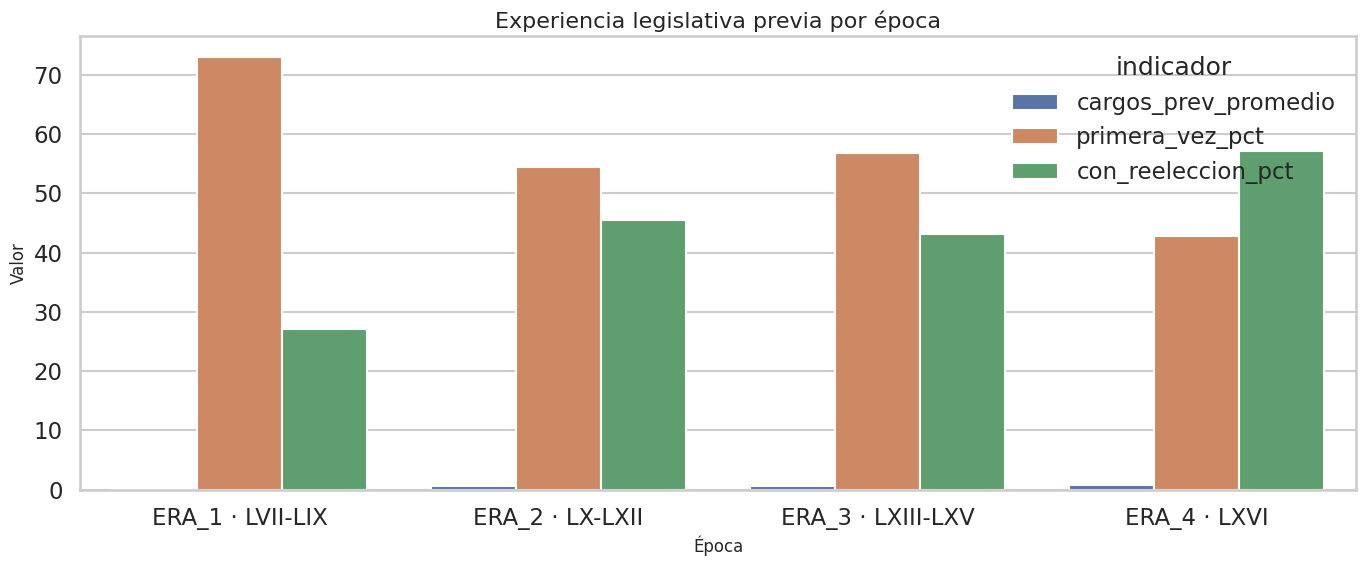

In [11]:
exp_prev_era = (
    plot_df.groupby("era_label")
    .agg(
        cargos_prev_promedio=("n_cargos_legislativos_prev", "mean"),
        primera_vez_pct=("n_cargos_legislativos_prev", lambda s: 100 * (s == 0).mean()),
        con_reeleccion_pct=("n_cargos_legislativos_prev", lambda s: 100 * (s >= 1).mean()),
    )
    .reset_index()
)

display(exp_prev_era.round(2))

exp_prev_long = exp_prev_era.melt(id_vars="era_label", var_name="indicador", value_name="valor")
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=exp_prev_long, x="era_label", y="valor", hue="indicador", ax=ax)
ax.set_title("Experiencia legislativa previa por época")
ax.set_xlabel("Época")
ax.set_ylabel("Valor")
plt.tight_layout()
plt.show()


## 8. Trayectorias acumuladas por época

,era_label,n_trayectoria_admin,n_trayectoria_politica,n_trayectoria_legislativa,n_trayectoria_empresarial
0,ERA_1 · LVII-LIX,2.96,7.38,0.68,1.57
1,ERA_2 · LX-LXII,3.52,6.74,0.80,1.90
2,ERA_3 · LXIII-LXV,3.06,4.79,0.82,1.51
3,ERA_4 · LXVI,3.06,4.48,1.15,1.39


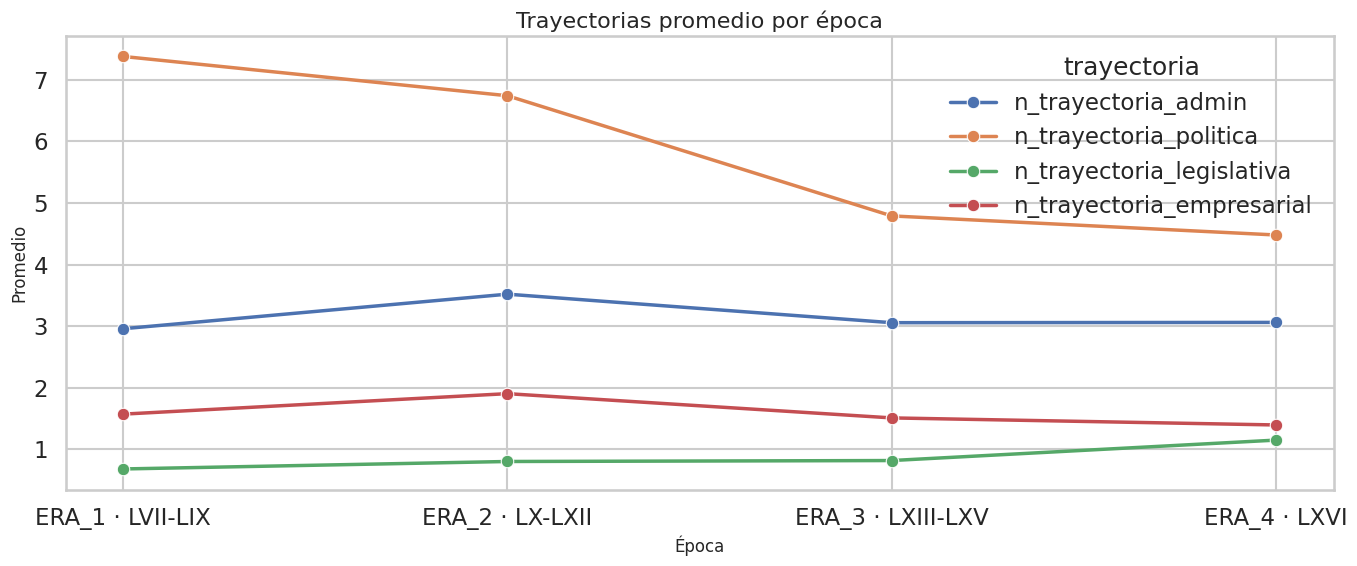

In [12]:
trayectorias_era = (
    plot_df.groupby("era_label")[[
        "n_trayectoria_admin",
        "n_trayectoria_politica",
        "n_trayectoria_legislativa",
        "n_trayectoria_empresarial",
    ]]
    .mean()
    .reset_index()
)

display(trayectorias_era.round(2))

trayectorias_long = trayectorias_era.melt(id_vars="era_label", var_name="trayectoria", value_name="promedio")
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=trayectorias_long, x="era_label", y="promedio", hue="trayectoria", marker="o", linewidth=2.5, ax=ax)
ax.set_title("Trayectorias promedio por época")
ax.set_xlabel("Época")
ax.set_ylabel("Promedio")
plt.tight_layout()
plt.show()


## 9. Comisiones por época

,era_label,comisiones_promedio,especiales_promedio,nodales_promedio,tematicas_promedio,lastre_promedio,preside_pct,lider_pct
0,ERA_1 · LVII-LIX,3.57,0.67,0.47,1.53,0.51,15.07,57.00
1,ERA_2 · LX-LXII,4.40,0.64,0.63,1.93,0.58,21.47,86.07
2,ERA_3 · LXIII-LXV,4.19,0.00,0.82,2.15,0.68,17.20,97.13
3,ERA_4 · LXVI,3.23,0.00,0.88,1.87,0.45,11.40,98.00


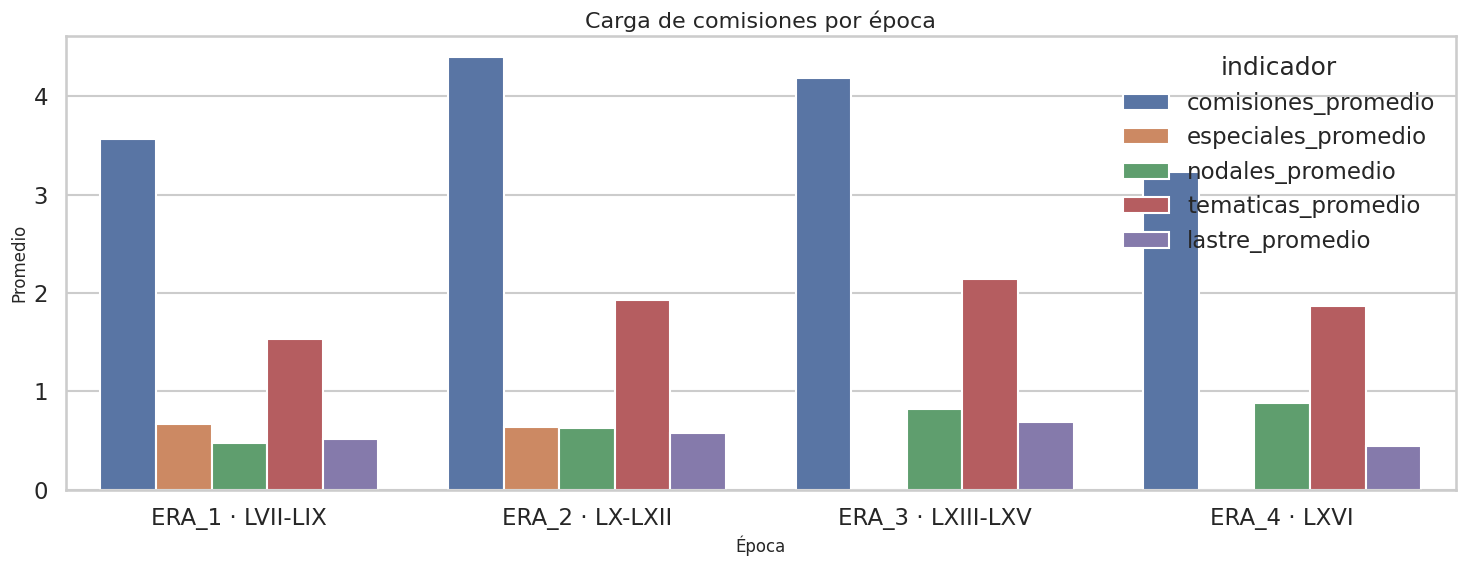

In [13]:
comisiones_era = (
    plot_df.groupby("era_label")
    .agg(
        comisiones_promedio=("n_comisiones", "mean"),
        especiales_promedio=("n_comisiones_especiales", "mean"),
        nodales_promedio=("n_comisiones_nodales", "mean"),
        tematicas_promedio=("n_comisiones_tematicas", "mean"),
        lastre_promedio=("n_comisiones_lastre", "mean"),
        preside_pct=("n_presidencias", lambda s: 100 * (s >= 1).mean()),
        lider_pct=("lider_comision", lambda s: 100 * s.mean()),
    )
    .reset_index()
)

display(comisiones_era.round(2))

comisiones_long = comisiones_era.melt(
    id_vars="era_label",
    value_vars=[
        "comisiones_promedio",
        "especiales_promedio",
        "nodales_promedio",
        "tematicas_promedio",
        "lastre_promedio",
    ],
    var_name="indicador",
    value_name="valor",
)

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(data=comisiones_long, x="era_label", y="valor", hue="indicador", ax=ax)
ax.set_title("Carga de comisiones por época")
ax.set_xlabel("Época")
ax.set_ylabel("Promedio")
plt.tight_layout()
plt.show()


,era_label,partido,n_comisiones_nodales,n_comisiones_tematicas,n_comisiones_lastre,total
9,ERA_1 · LVII-LIX,PVEM,0.68,1.82,0.55,3.05
8,ERA_1 · LVII-LIX,PT,0.88,1.69,0.31,2.88
6,ERA_1 · LVII-LIX,PRI,0.49,1.56,0.52,2.57
5,ERA_1 · LVII-LIX,PRD,0.42,1.50,0.53,2.44
3,ERA_1 · LVII-LIX,PAN,0.44,1.48,0.49,2.41
20,ERA_2 · LX-LXII,PVEM,0.85,2.16,0.72,3.73
13,ERA_2 · LX-LXII,MORENA,0.42,2.42,0.83,3.67
18,ERA_2 · LX-LXII,PRI,0.64,2.04,0.61,3.29
17,ERA_2 · LX-LXII,PRD,0.63,1.89,0.54,3.05
14,ERA_2 · LX-LXII,PAN,0.57,1.82,0.56,2.95


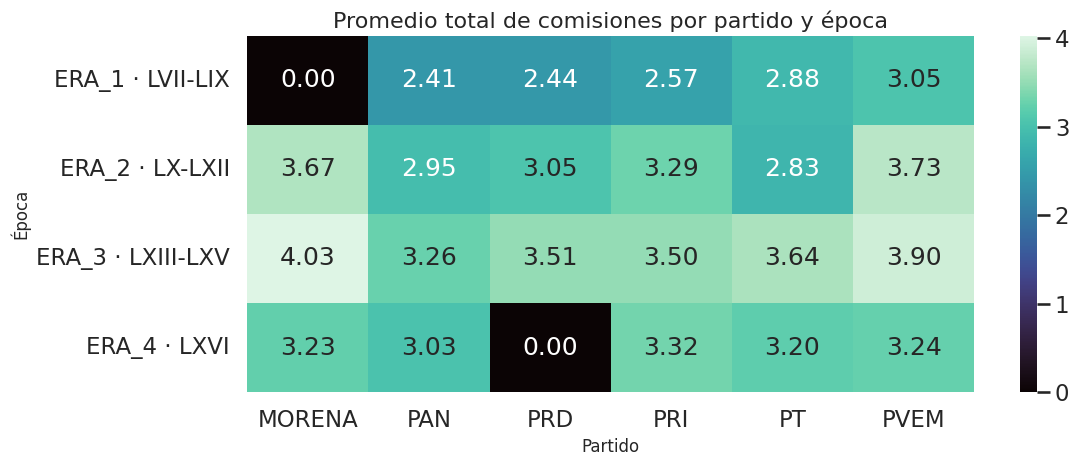

In [14]:
party_commission_era = (
    plot_df.groupby(["era_label", "partido"])[[
        "n_comisiones_nodales",
        "n_comisiones_tematicas",
        "n_comisiones_lastre",
    ]]
    .mean()
    .reset_index()
)

party_focus = (
    plot_df["partido"].value_counts()
    .head(6)
    .index
)

party_commission_focus = party_commission_era[party_commission_era["partido"].isin(party_focus)].copy()
party_commission_focus["total"] = (
    party_commission_focus["n_comisiones_nodales"]
    + party_commission_focus["n_comisiones_tematicas"]
    + party_commission_focus["n_comisiones_lastre"]
)

display(party_commission_focus.sort_values(["era_label", "total"], ascending=[True, False]).head(24).round(2))

party_heat = party_commission_focus.pivot(index="era_label", columns="partido", values="total").fillna(0)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(party_heat, annot=True, fmt=".2f", cmap="mako", ax=ax)
ax.set_title("Promedio total de comisiones por partido y época")
ax.set_xlabel("Partido")
ax.set_ylabel("Época")
plt.tight_layout()
plt.show()


## 10. Correlaciones con número de comisiones por época

,n_trayectoria_admin,n_trayectoria_politica,nivel_cargo_max,n_trayectoria_empresarial,n_cargos_legislativos_prev,edad_al_tomar_cargo
ERA_1 · LVII-LIX,0.136,0.158,0.108,0.030,0.038,-0.062
ERA_2 · LX-LXII,0.072,0.060,0.039,0.039,0.029,-0.068
ERA_3 · LXIII-LXV,0.039,0.031,0.033,0.027,0.006,-0.107
ERA_4 · LXVI,0.037,-0.039,-0.009,0.012,-0.004,0.016


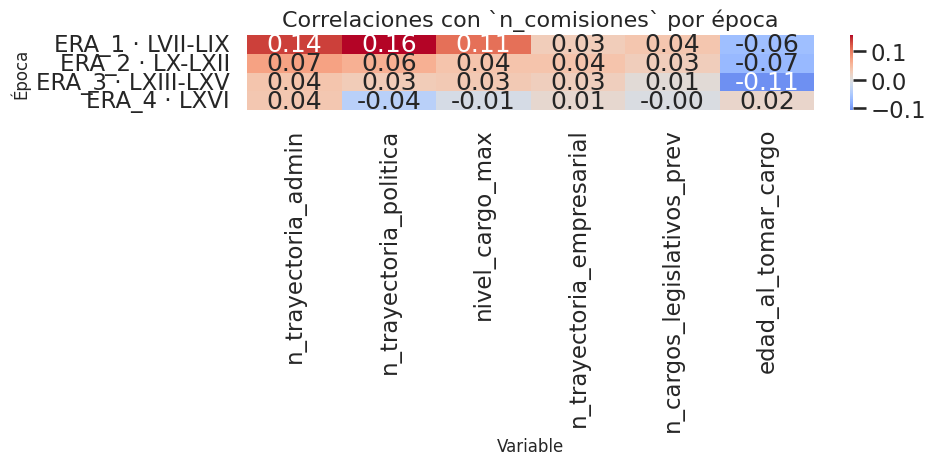

In [15]:
corr_cols = [
    "n_comisiones",
    "n_trayectoria_admin",
    "n_trayectoria_politica",
    "nivel_cargo_max",
    "n_trayectoria_empresarial",
    "n_cargos_legislativos_prev",
    "edad_al_tomar_cargo",
]

corr_by_era = []
for era in era_order:
    block = plot_df.loc[plot_df["era"] == era, corr_cols].corr(numeric_only=True)
    target_corr = block["n_comisiones"].drop("n_comisiones").rename(era_label_map[era])
    corr_by_era.append(target_corr)

corr_comp = pd.concat(corr_by_era, axis=1).T
display(corr_comp.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(corr_comp, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlaciones con `n_comisiones` por época")
ax.set_xlabel("Variable")
ax.set_ylabel("Época")
plt.tight_layout()
plt.show()


## 11. Lectura rápida

In [16]:
hallazgos = pd.DataFrame({
    "métrica": [
        "Edad promedio",
        "Trayectoria política promedio",
        "Trayectoria legislativa promedio",
        "Promedio comisiones nodales",
        "Promedio comisiones temáticas",
        "% con posgrado",
    ],
    "ERA_1": [
        plot_df.loc[plot_df["era"] == "ERA_1", "edad_al_tomar_cargo"].mean(),
        plot_df.loc[plot_df["era"] == "ERA_1", "n_trayectoria_politica"].mean(),
        plot_df.loc[plot_df["era"] == "ERA_1", "n_trayectoria_legislativa"].mean(),
        plot_df.loc[plot_df["era"] == "ERA_1", "n_comisiones_nodales"].mean(),
        plot_df.loc[plot_df["era"] == "ERA_1", "n_comisiones_tematicas"].mean(),
        100 * plot_df.loc[plot_df["era"] == "ERA_1", "tiene_posgrado"].mean(),
    ],
    "ERA_4": [
        plot_df.loc[plot_df["era"] == "ERA_4", "edad_al_tomar_cargo"].mean(),
        plot_df.loc[plot_df["era"] == "ERA_4", "n_trayectoria_politica"].mean(),
        plot_df.loc[plot_df["era"] == "ERA_4", "n_trayectoria_legislativa"].mean(),
        plot_df.loc[plot_df["era"] == "ERA_4", "n_comisiones_nodales"].mean(),
        plot_df.loc[plot_df["era"] == "ERA_4", "n_comisiones_tematicas"].mean(),
        100 * plot_df.loc[plot_df["era"] == "ERA_4", "tiene_posgrado"].mean(),
    ],
})
hallazgos["cambio_ERA4_menos_ERA1"] = hallazgos["ERA_4"] - hallazgos["ERA_1"]
display(hallazgos.round(2))


,métrica,ERA_1,ERA_4,cambio_ERA4_menos_ERA1
0,Edad promedio,44.82,48.37,3.55
1,Trayectoria política promedio,7.38,4.48,-2.90
2,Trayectoria legislativa promedio,0.68,1.15,0.47
3,Promedio comisiones nodales,0.47,0.88,0.40
4,Promedio comisiones temáticas,1.53,1.87,0.34
5,% con posgrado,25.40,38.00,12.60


## Notas

- Notebook queda en español, pero usa mismas columnas y misma lógica base que `report_graphs_20260421.ipynb`.
- Diferencia central: aquí toda comparación se hace por `ERA_1` a `ERA_4`.
- `ERA_3` se interpreta como `LXIII-LXV`, siguiendo tu instrucción.
